In [1]:
%cd /Users/floriankokoszka/Desktop/notebooks
%pwd

%run mc_startup.ipynb
%run myfunctions.ipynb

import os

import geopandas as gpd
#cities = gpd.read_file(gpd.datasets.get_path('naturalearth_cities'))
#cities.head()
#http://www.xavierdupre.fr/app/papierstat/helpsphinx/notebooks/enedis_cartes.html#geopandas


def iserror(func, *args, **kw):
    try:
        func(*args, **kw)
        return False
    except Exception:
        return True

def isfloat(num):
    try:
        float(num)
        return True
    except ValueError:
        return False
    
    
import scipy.io as sio


/Users/floriankokoszka/Desktop/notebooks


In [402]:
####### DATA PATH
#####
###
#
data_pth = '/Volumes/DENISE/data/glider/teresa/data/' 
meta_pth = '/Volumes/DENISE/data/glider/teresa/meta/' 
out_pth = '/Volumes/DENISE/data/glider/teresa/out/' 

In [5]:
dir_list = os.listdir(data_pth)
dirs = []
for i in range(0,len(dir_list)):
    if dir_list[i].startswith('.') == False:
        dirs.append(dir_list[i])
dir_list = np.array(dirs)
dir_list

array(['teresa_microrider_2015_agosto', 'teresa_microrider_2015_july',
       'teresa_microrider_2017_marzo_aprile',
       'teresa_microrider_2017_MISC', 'teresa_microrider_2018_maggio',
       'teresa_microrider_2022', 'teresa_microrider_2023'], dtype='<U35')

In [6]:
import glob
import os
import time

M = []
P = []
F = []

for d in range(0,len(dir_list)):
    dir_pth = data_pth + dir_list[d] +'/data/'
    print(dir_pth)
    
    #----------------------------------
    file_typ = '.P'
    liste = filter( os.path.isfile, glob.glob(dir_pth + '*'+file_typ) )
    liste = sorted( liste,key = os.path.getmtime)
    for file_path in liste:
        timestamp_str = time.strftime('%m/%d/%Y :: %H:%M:%S',time.gmtime(os.path.getmtime(file_path))) 
    liste_P = liste
    #
    P_liste = []
    for i in range(0,len(liste_P)):
        P_liste.append(liste_P[i].split('/')[-1][0:-2])
     
    #----------------------------------
    file_typ = '.mat'
    liste = filter( os.path.isfile, glob.glob(dir_pth + '*'+file_typ) )
    liste = sorted( liste,key = os.path.getmtime)
    for file_path in liste:
        timestamp_str = time.strftime('%m/%d/%Y :: %H:%M:%S',time.gmtime(os.path.getmtime(file_path))) 
    liste_MAT = liste
    #
    MAT_liste = []
    for i in range(0,len(liste_MAT)):
        MAT_liste.append(liste_MAT[i].split('/')[-1][0:-4])
    
    #----------------------------------
    liste_FAIL = []
    for i in range(0,len(P_liste)):
        if (P_liste[i] in MAT_liste) == False:
            liste_FAIL.append(liste_P[i])
     
    #----------------------------------
    P = P + liste_P 
    M = M + liste_MAT
    F = F + liste_FAIL 

FS = []
for i in range(0,len(M)):
    file_size = os.stat((M[i]))
    #print("file size :", file_size.st_size/1e6, "M bytes")
    FS.append(file_size.st_size/1e6)
FS = np.array(FS)

print('\n:',len(M),'x .mat files')
print('total of ',np.round(np.nansum(FS)/1e3,0).astype(int),'Go of .mat')


FS = []
for i in range(0,len(P)):
    file_size = os.stat((P[i]))
    #print("file size :", file_size.st_size/1e6, "M bytes")
    FS.append(file_size.st_size/1e6)
FS = np.array(FS)

print('\n:',len(P),'x .P files')
print('total of ',np.round(np.nansum(FS)/1e3,0).astype(int),' Go of .P files')


/Volumes/DENISE/data/glider/teresa/data/teresa_microrider_2015_agosto/data/
/Volumes/DENISE/data/glider/teresa/data/teresa_microrider_2015_july/data/
/Volumes/DENISE/data/glider/teresa/data/teresa_microrider_2017_marzo_aprile/data/
/Volumes/DENISE/data/glider/teresa/data/teresa_microrider_2017_MISC/data/
/Volumes/DENISE/data/glider/teresa/data/teresa_microrider_2018_maggio/data/
/Volumes/DENISE/data/glider/teresa/data/teresa_microrider_2022/data/
/Volumes/DENISE/data/glider/teresa/data/teresa_microrider_2023/data/

: 657 x .mat files
total of  601 Go of .mat

: 922 x .P files
total of  99  Go of .P files


In [13]:
# print the lists

pth = meta_pth+'/lists/'

L = M
lname = 'liste_MAT.txt'
file_object = open(pth+lname, 'w')
file_object.close()
#
file_object = open(pth+lname, 'a')
file_object.write(str(len(L))+' files \n')
file_object.close()
#
for l in range(0,len(L)):
    file_object = open(pth+lname, 'a')
    file_object.write(L[l]+'\n')
    file_object.close()

    
L = P
lname = 'liste_P.txt'
file_object = open(pth+lname, 'w')
file_object.close()
#
file_object = open(pth+lname, 'a')
file_object.write(str(len(L))+' files \n')
file_object.close()

for l in range(0,len(L)):
    file_object = open(pth+lname, 'a')
    file_object.write(L[l]+'\n')
    file_object.close()
    
    
L = F
lname = 'liste_FAIL.txt'
file_object = open(pth+lname, 'w')
file_object.close()
#
file_object = open(pth+lname, 'a')
file_object.write(str(len(L))+' files \n')
file_object.close()

for l in range(0,len(L)):
    file_object = open(pth+lname, 'a')
    file_object.write(L[l]+'\n')
    file_object.close()

In [291]:
from scipy.signal import argrelextrema


columnz = ['fn','fnshort','date','time','N_slow','N_fast','delta_t',
           'P_min','P_max','P_mean','P_std',
           'T2_min','T2_max','T2_mean','T2_std',
           'T1_min','T1_max','T1_mean','T1_std',
    'Tfast_min','Tfast_max','Tfast_mean','Tfast_std',
    'W_min','W_max','W_mean','W_std',
    'speed_min','speed_max','speed_mean','speed_std',
    'sh1_min','sh1_max','sh1_mean','sh1_std',
    'sh2_min','sh2_max','sh2_mean','sh2_std',
    'V_Bat_min','V_Bat_max','V_Bat_mean','V_Bat_std',
    'Incl_Y_min','Incl_Y_max','Incl_Y_mean','Incl_Y_std',
    'Incl_X_min','Incl_X_max','Incl_X_mean','Incl_X_std',
    'N_profiles_downward_fast','N_profiles_upward_fast',
        'peaks_fast_i','peaks_fast_e','difpres_fast',
        'N_profiles_downward_slow','N_profiles_upward_slow',
        'peaks_slow_i','peaks_slow_e','difpres_slow',
        'setupfilestr']

i0 = 0
i0 = 321
custom_liste = np.concatenate((np.arange(0,320),np.arange(321,len(M))),0)

META = []
for ii in range(0,len(custom_liste)):
    
    per = np.round((ii / len(custom_liste)) * 100 ,1) 
    if per % 2.0 == 0:
        print(f"Progress : {per}%")
    
    i = custom_liste[ii]
    fn = str(M[i])
    fnshort = fn.split('/')[-1][0:-4]
    # # # # # # # 
    matstruct_contents = sio.loadmat(fn)
    # # # # # # # 
    
    
    # short -----------------------------------------
    setupfilestr = matstruct_contents['setupfilestr']
    
    t_slow = np.array(matstruct_contents['t_slow']).flatten()
    t_fast = np.array(matstruct_contents['t_fast']).flatten()

    date = np.array(matstruct_contents['date'])[0]
    time = np.array(matstruct_contents['time'])[0]
    T1_slow = np.array(matstruct_contents['T1_slow']).flatten()
    T2_slow = np.array(matstruct_contents['T2_slow']).flatten()
    P_slow = np.array(matstruct_contents['P_slow']).flatten()
    W_slow = np.array(matstruct_contents['W_slow']).flatten()
    speed_slow = np.array(matstruct_contents['speed_slow']).flatten()

    sh1 = np.array(matstruct_contents['sh1']).flatten()
    sh2 = np.array(matstruct_contents['sh2']).flatten()
    temperature_fast = np.array(matstruct_contents['temperature_fast']).flatten()
    P_fast = np.array(matstruct_contents['P_fast']).flatten()

    V_Bat = np.array(matstruct_contents['V_Bat']).flatten()
    Incl_Y = np.array(matstruct_contents['Incl_Y']).flatten()
    Incl_X = np.array(matstruct_contents['Incl_X']).flatten()


    # light -----------------------------------------
    t_i = np.arange(t_slow[0],t_slow[-1],1)
    P_i = interpholes(t_slow,P_slow,t_i)
    T2_i = interpholes(t_slow,T2_slow,t_i)
    T1_i = interpholes(t_slow,T1_slow,t_i)
    W_i = interpholes(t_slow,W_slow,t_i)
    speed_i = interpholes(t_slow,speed_slow,t_i)
    
    V_Bat_i = interpholes(t_slow,V_Bat,t_i)
    Incl_Y_i = interpholes(t_slow,Incl_Y,t_i)
    Incl_X_i = interpholes(t_slow,Incl_X,t_i)
    
    
    sh1_i = interpholes(t_fast,sh1,t_i)
    sh2_i = interpholes(t_fast,sh2,t_i)
    temperature_fast_i = interpholes(t_fast,temperature_fast,t_i)
    
    
    #--------- PROFILES ? ----------------------------
    from scipy.signal import argrelextrema

    ithresh = 10000
    #------
    y_data = P_slow
    peaks_ind = argrelextrema(y_data,np.less)
    peaks_ind = peaks_ind[0]
    f = np.where(np.diff(peaks_ind)> ithresh)[0]
    peaks_ind = peaks_ind[f]
    peaks_ind = list(peaks_ind)
    peaks_ind.append(len(t_slow)-1)
    peaks_slow = np.array(peaks_ind)

    #------
    y_data = P_fast
    peaks_ind = argrelextrema(y_data,np.less)
    peaks_ind = peaks_ind[0]
    f = np.where(np.diff(peaks_ind)> ithresh*10)[0]
    peaks_ind = peaks_ind[f]
    peaks_ind = list(peaks_ind)
    peaks_ind.append(len(t_fast)-1)
    peaks_fast = np.array(peaks_ind)


    if len(peaks_fast) == 1:
        peaks_fast = np.concatenate(([0],peaks_fast),axis=0)
        peaks_slow = np.concatenate(([0],peaks_slow),axis=0)

    peaks_fast_i = peaks_fast[0:-1]
    peaks_fast_e = peaks_fast[1:]
    difpres_fast = np.diff(P_fast[peaks_fast])
    #print(len(difpres_fast))
    f = np.where(difpres_fast > 0)[0]
    N_profiles_downward_fast = len(f)
    f = np.where(difpres_fast < 0)[0]
    N_profiles_upward_fast = len(f)
    
    peaks_slow_i = peaks_slow[0:-1]
    peaks_slow_e = peaks_slow[1:]
    difpres_slow = np.diff(P_slow[peaks_slow])
    #print(len(difpres_slow))
    f = np.where(difpres_slow > 0)[0]
    N_profiles_downward_slow = len(f)
    f = np.where(difpres_slow < 0)[0]
    N_profiles_upward_slow = len(f)
    
    



    wantplot = 1 
    if wantplot == 1:
        # plot -----------------------------------------
        fig , axs =  plt.subplots(1,4, figsize=(15,3))

        ax = axs[0]
        ax.plot(t_i,P_i,'k')
        ax.invert_yaxis()
        ax.set_title(date+' '+time+' '+fn.split('/')[-1])
        ax.set_ylabel('Pressure $(db)$')
        ax.set_xlabel('Time $(s)$')
        ax.grid(alpha=.25)
        ax.plot(t_slow[peaks_slow],P_slow[peaks_slow],'ro')

        ax = axs[1]
        ax.plot(sh1_i,P_i,color='b',label='sh1 i',alpha=.5)
        ax.plot(sh2_i,P_i,color='r',label='sh2 i',alpha=.5)
        ax.invert_yaxis()
        ax.set_ylabel('Pressure $(db)$')
        ax.set_xlabel('sh $(s^{-1})$')
        ax.legend(fontsize=8)
        ax.grid(alpha=.25)

        ax = axs[2]
        ax.plot(temperature_fast_i,P_i,color='b',label='Temp fast i',alpha=.5)
        ax.invert_yaxis()
        ax.set_ylabel('Pressure $(db)$')
        ax.set_xlabel('T $(C^{o})$')
        ax.legend(fontsize=8)
        ax.grid(alpha=.25)

        ax = axs[3]
        ax.hist(T1_i,bins=np.arange(10,35,0.1),color='b',label='T1 i',alpha=.5)
        ax.hist(T2_i,bins=np.arange(10,35,0.1),color='r',label='T2 i',alpha=.5)
        ax.set_title('')
        ax.set_xlabel('T $(C^{o})$')
        ax.legend(fontsize=8)
        ax.grid(alpha=.25)

        figname = date+'_'+fn.split('/')[-1][0:-4]
        fig.tight_layout(pad=1)
        fig.savefig(meta_pth+'plots/'+ figname+ '.pdf')
        plt.close(fig)
        
       
    #-------------------------
    fn
    fnshort
    date
    time

    N_slow = len(t_slow)
    N_fast = len(t_fast)

    delta_t = (t_i[-1]-t_i[0])

    x = P_i*1
    P_min = np.nanmin(x)
    P_max = np.nanmax(x)
    P_mean = np.nanmean(x)
    P_std = np.nanstd(x)
    
    x = T2_i*1
    T2_min  = np.nanmin(x)
    T2_max  = np.nanmax(x)
    T2_mean = np.nanmean(x)
    T2_std  = np.nanstd(x)

    x = T1_i*1
    T1_min = np.nanmin(x)
    T1_max = np.nanmax(x)
    T1_mean = np.nanmean(x)
    T1_std = np.nanstd(x)


    x = temperature_fast_i*1
    Tfast_min = np.nanmin(x)
    Tfast_max = np.nanmax(x)
    Tfast_mean = np.nanmean(x)
    Tfast_std = np.nanstd(x)
    
    x = W_i*1
    W_min = np.nanmin(x)
    W_max = np.nanmax(x)
    W_mean = np.nanmean(x)
    W_std = np.nanstd(x)


    x = speed_i*1
    speed_min = np.nanmin(x)
    speed_max = np.nanmax(x)
    speed_mean = np.nanmean(x)
    speed_std = np.nanstd(x)

    x = sh1_i*1
    sh1_min = np.nanmin(x)
    sh1_max = np.nanmax(x)
    sh1_mean = np.nanmean(x)
    sh1_std = np.nanstd(x)

    x = sh2_i*1
    sh2_min = np.nanmin(x)
    sh2_max = np.nanmax(x)
    sh2_mean = np.nanmean(x)
    sh2_std = np.nanstd(x)


    x = V_Bat_i*1
    V_Bat_min = np.nanmin(x)
    V_Bat_max = np.nanmax(x)
    V_Bat_mean = np.nanmean(x)
    V_Bat_std = np.nanstd(x)

    x = Incl_Y_i*1
    Incl_Y_min = np.nanmin(x)
    Incl_Y_max = np.nanmax(x)
    Incl_Y_mean = np.nanmean(x)
    Incl_Y_std = np.nanstd(x)

    x = Incl_X_i*1
    Incl_X_min = np.nanmin(x)
    Incl_X_max = np.nanmax(x)
    Incl_X_mean = np.nanmean(x)
    Incl_X_std = np.nanstd(x)

    #
    #-------------------------
        
    
    meta = [fn,fnshort,date,time,N_slow,N_fast,delta_t,
        P_min, P_max, P_mean,P_std,
        T2_min,T2_max,T2_mean,T2_std,
        T1_min,T1_max,T1_mean,T1_std,
        Tfast_min,Tfast_max,Tfast_mean,Tfast_std,
        W_min,W_max,W_mean,W_std,
        speed_min,speed_max,speed_mean,speed_std,
        sh1_min,sh1_max,sh1_mean,sh1_std,
        sh2_min,sh2_max,sh2_mean,sh2_std,
        V_Bat_min,V_Bat_max,V_Bat_mean,V_Bat_std,
        Incl_Y_min,Incl_Y_max,Incl_Y_mean,Incl_Y_std,
        Incl_X_min,Incl_X_max,Incl_X_mean,Incl_X_std,
    
        N_profiles_downward_fast,N_profiles_upward_fast,
        peaks_fast_i,peaks_fast_e,difpres_fast,
        N_profiles_downward_slow,N_profiles_upward_slow,
        peaks_slow_i,peaks_slow_e,difpres_slow,
        setupfilestr]
    
    
    META.append(meta)
print('LOOP FINISHED')

META = pd.DataFrame(META)
META.set_axis(columnz, axis="columns", inplace=True)
META.sort_values(by='date', inplace = True) 

META.to_csv(meta_pth+'/META.csv', index = False)
print('META STEP DONE')   

Progress : 0.0%
Progress : 2.0%
Progress : 4.0%
Progress : 12.0%
Progress : 14.0%
Progress : 16.0%
Progress : 18.0%
Progress : 20.0%
Progress : 22.0%
Progress : 28.0%
Progress : 30.0%
Progress : 32.0%
Progress : 34.0%
Progress : 36.0%
Progress : 38.0%
Progress : 46.0%
Progress : 48.0%
Progress : 50.0%
Progress : 52.0%
Progress : 54.0%
Progress : 62.0%
Progress : 64.0%
Progress : 66.0%
Progress : 68.0%
Progress : 70.0%
Progress : 72.0%
Progress : 78.0%
Progress : 80.0%
Progress : 82.0%
Progress : 84.0%
Progress : 86.0%
Progress : 88.0%
Progress : 96.0%
Progress : 98.0%
LOOP FINISHED
META STEP DONE


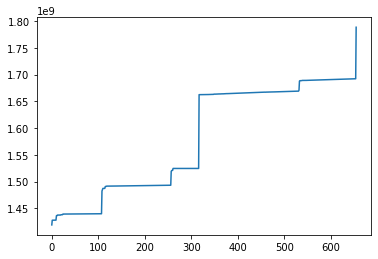

In [389]:
date = np.array(META['date'])
time = np.array(META['time'])
#
DT = []
TS = []
yyyy = []
mm = []
dd = []
HH = []
MM = []
SS = []
for i in range(0,len(date)):
    dt = datetime.strptime(date[i]+' '+time[i][0:-4], "%Y-%m-%d %H:%M:%S")
    DT.append(dt)
    yyyy.append(dt.year)
    mm.append(dt.month)
    dd.append(dt.day)
    HH.append(dt.hour)
    MM.append(dt.minute)
    SS.append(dt.second)
    TS.append(dt.timestamp())
    
DT = np.array(DT)
TS = np.array(TS)
yyyy = np.array(yyyy)
mm = np.array(mm)
dd = np.array(dd)
HH = np.array(HH)
MM = np.array(MM)
SS = np.array(SS)

yyyymm = yyyy + mm/13
ud = np.unique(yyyy)
F = []
for u in range(0,len(ud)):
    f = np.where(yyyy == ud[u])[0][0]
    F.append(f)
F = np.array(F)

plt.plot(TS)

In [383]:
META.columns

Index(['fn', 'fnshort', 'date', 'time', 'N_slow', 'N_fast', 'delta_t', 'P_min',
       'P_max', 'P_mean', 'P_std', 'T2_min', 'T2_max', 'T2_mean', 'T2_std',
       'T1_min', 'T1_max', 'T1_mean', 'T1_std', 'Tfast_min', 'Tfast_max',
       'Tfast_mean', 'Tfast_std', 'W_min', 'W_max', 'W_mean', 'W_std',
       'speed_min', 'speed_max', 'speed_mean', 'speed_std', 'sh1_min',
       'sh1_max', 'sh1_mean', 'sh1_std', 'sh2_min', 'sh2_max', 'sh2_mean',
       'sh2_std', 'V_Bat_min', 'V_Bat_max', 'V_Bat_mean', 'V_Bat_std',
       'Incl_Y_min', 'Incl_Y_max', 'Incl_Y_mean', 'Incl_Y_std', 'Incl_X_min',
       'Incl_X_max', 'Incl_X_mean', 'Incl_X_std', 'N_profiles_downward_fast',
       'N_profiles_upward_fast', 'peaks_fast_i', 'peaks_fast_e',
       'difpres_fast', 'N_profiles_downward_slow', 'N_profiles_upward_slow',
       'peaks_slow_i', 'peaks_slow_e', 'difpres_slow', 'setupfilestr'],
      dtype='object')

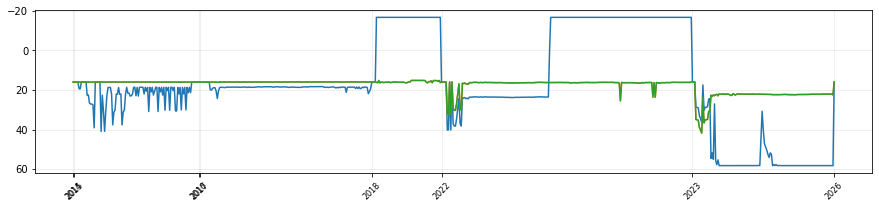

In [401]:
fig , axs =  plt.subplots(1,1, figsize=(15,3))

ax = axs
ax.plot(META['T1_mean'])
ax.plot(META['T2_mean'])
ax.plot(META['Tfast_mean'])

#ax.plot(META['sh2_mean'])

ax.invert_yaxis()
#ax.set_title(date+' '+time+' '+fn.split('/')[-1])
#ax.set_ylabel('Pressure $(db)$')
#ax.set_xlabel('Time $(s)$')
ax.set_xticks(F)
ax.set_xticklabels(np.round(yyyy[F],2),fontsize=8,rotation=45)

#ax.set_xlim(450,500)
ax.grid(alpha=.25)

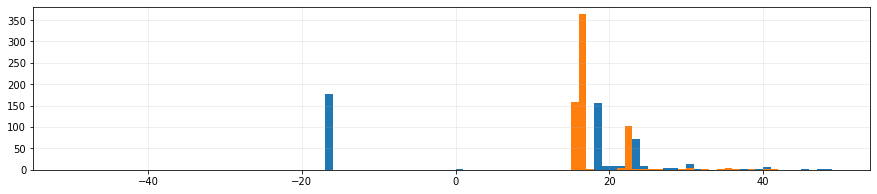

In [400]:
fig , axs =  plt.subplots(1,1, figsize=(15,3))
b = np.arange(-50,50,1)
ax = axs
ax.hist(META['T1_mean'],bins=b)
ax.hist(META['T2_mean'],bins=b)
ax.grid(alpha=0.25)


# Load epsilons .mat

In [714]:
import glob
import os
import time

E = []

dir_pth = out_pth
print(dir_pth)

#----------------------------------
file_typ = '.mat'
liste = filter( os.path.isfile, glob.glob(dir_pth + '*'+file_typ) )
liste = sorted( liste,key = os.path.getmtime)
for file_path in liste:
    timestamp_str = time.strftime('%m/%d/%Y :: %H:%M:%S',time.gmtime(os.path.getmtime(file_path))) 
liste_E = liste
#
E_liste = []
for i in range(0,len(liste_E)):
    E_liste.append(liste_E[i].split('/')[-1][0:-4])

#----------------------------------
E = E + liste_E 

FS = []
for i in range(0,len(E)):
    file_size = os.stat((E[i]))
    #print("file size :", file_size.st_size/1e6, "M bytes")
    FS.append(file_size.st_size/1e3)
FS = np.array(FS)

print('\n:',len(E),'x .mat files')
print('total of ',np.round(np.nansum(FS)/1e3,0).astype(int),'Mo of .mat')

/Volumes/DENISE/data/glider/teresa/out/

: 553 x .mat files
total of  104 Mo of .mat


In [720]:
import mat73

TERESA_microrider_DAT_045_2015-07-06_12-18
ERROR! Session/line number was not unique in database. History logging moved to new session 1829
TERESA_microrider_DAT_046_2015-07-06_14-15
TERESA_microrider_DAT_048_2015-07-20_10-18
TERESA_microrider_DAT_049_2015-07-20_11-59
TERESA_microrider_DAT_050_2015-07-20_12-25
TERESA_microrider_DAT_051_2015-07-20_12-45
TERESA_microrider_DAT_052_2015-07-20_13-22
TERESA_microrider_DAT_053_2015-07-20_14-14
TERESA_microrider_DAT_058_2015-08-11_16-10
ze.size = 1
TERESA_microrider_DAT_059_2015-08-11_16-19
TERESA_microrider_DAT_061_2015-08-12_6-46
TERESA_microrider_DAT_062_2015-08-12_6-55
TERESA_microrider_DAT_063_2015-08-12_7-46
TERESA_microrider_DAT_064_2015-08-12_8-33
TERESA_microrider_DAT_065_2015-08-12_9-22
TERESA_microrider_DAT_066_2015-08-12_12-31
TERESA_microrider_DAT_067_2015-08-12_19-9
TERESA_microrider_DAT_068_2015-08-13_1-11
TERESA_microrider_DAT_069_2015-08-13_2-5
TERESA_microrider_DAT_070_2015-08-13_7-50
TERESA_microrider_DAT_071_2015-08-13_8-26

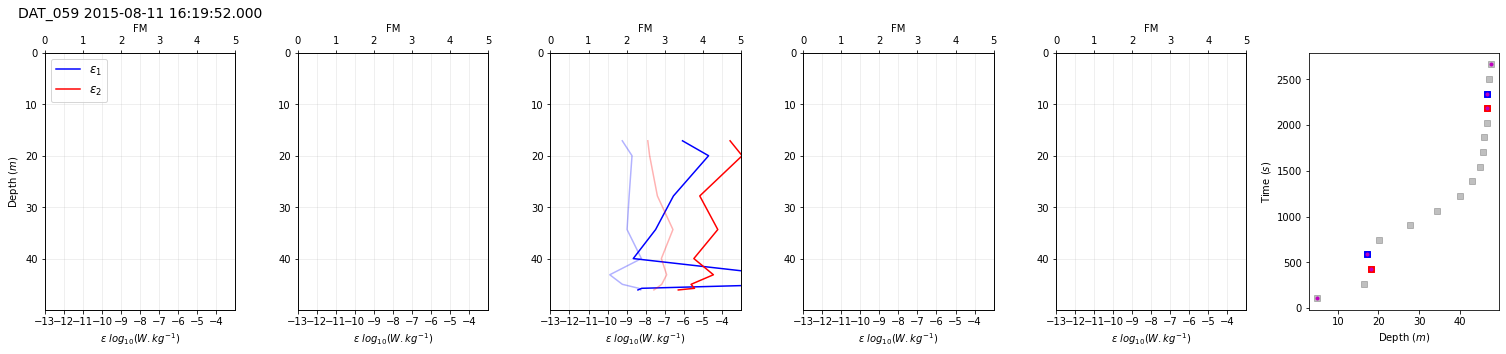

In [719]:
for i in range(0,len(E)):
    fn = str(E[i])
    fnshort = fn.split('/')[-1][0:-4]
    print(fnshort)
    # # # # # # # 
    #matstruct_contents = sio.loadmat(fn)
    matstruct_contents = mat73.loadmat(fn)
    X = matstruct_contents['QUICK_EPSILON']

    date = np.array(X['date_profile'])
    time = np.array(X['time_profile'])

    FM = np.array(X['FM'])
    fm1 = np.array(X['fm1'])
    fm2 = np.array(X['fm2'])
    e1 = np.array(X['e1'])
    e2 = np.array(X['e2'])

    te = np.array(X['te'])
    ze = np.array(X['ze'])
    PE = np.array(X['PE'])

    if ze.size > 1:
        # print('dz : ',np.round(np.nanmean(np.abs(np.diff(ze))),2),'m')


        y_data = ze
        peaks_ind = argrelextrema(y_data,np.greater)
        peaks_ind = peaks_ind[0]

        y_data = ze
        peaks_mon = argrelextrema(y_data,np.less)
        peaks_mon = peaks_mon[0]

        i0 = 0 
        iN = ze.size-1
        ii = np.concatenate((peaks_ind,peaks_mon),0)
        ii = np.concatenate(([i0],ii),0)
        ii = np.concatenate((ii,[iN]),0)
        ii = np.sort(ii)

        # print(ii)

        ploooot = 0
        if ploooot == 1:
            fig , axs =  plt.subplots(1,1, figsize=(5,3))
            ax = axs
            ax.plot(te,ze,'s',color='gray',alpha=0.5)
            ax.invert_yaxis()
            ax.plot(te[peaks_ind],ze[peaks_ind],'rs')
            ax.plot(te[peaks_mon],ze[peaks_mon],'bs')
            ax.plot(te[ii],ze[ii],'m.')
            ax.set_ylabel('Depth $(m)$')
            ax.set_xlabel('Time $(s)$')

        #------------------------------------------------------------ 
        fig , axs =  plt.subplots(1,len(ii), figsize=(3.5*(len(ii)),5))

        for i in range(0,len(ii)-1):
            i1 = ii[i]
            i2 = ii[i+1]-1
            #print(i1,i2)

            ax = axs[i]
            ax.plot(np.log10(e1[i1:i2]),ze[i1:i2],color='b',label='$\epsilon_1$')
            ax.plot(np.log10(e2[i1:i2]),ze[i1:i2],color='r',label='$\epsilon_2$')
            ax.set_xticks(xax)
            ax.grid(alpha=.25)
            ax.invert_yaxis()
            ax.set_ylim(1.05*np.nanmax(ze),0)
            ax.set_xlim(-13,-3)

            ax2 = ax.twiny()
            ax2.plot((fm1[i1:i2]),ze[i1:i2],alpha=0.3,color='b')
            ax2.plot((fm2[i1:i2]),ze[i1:i2],alpha=0.3,color='r')
            ax2.set_xlim(0,5)
            ax2.set_ylim(1.05*np.nanmax(ze),0)    
            ax.set_xlabel('$\epsilon$ $log_{10}(W.kg^{-1})$')
            ax2.set_xlabel('FM')

            if i == 0:
                ax.set_ylabel('Depth $(m)$')
                ax.legend(fontsize=12)


        ax = axs[i+1]
        ax.plot(ze,te,'s',color='gray',alpha=0.5)
        #ax.invert_yaxis()
        ax.plot(ze[peaks_ind],te[peaks_ind],'rs')
        ax.plot(ze[peaks_mon],te[peaks_mon],'bs')
        ax.plot(ze[ii],te[ii],'m.')
        ax.set_xlabel('Depth $(m)$')
        ax.set_ylabel('Time $(s)$')

        ax = axs[0]
        ax.set_title(fnshort[18:25]+' '+str(date)+' '+str(time),fontsize=14)

        fig.tight_layout(pad=1)

        figname = fnshort
        fig.savefig(meta_pth+'plots/'+ figname+ '.pdf')
        plt.close(fig)
        #print(len(te))

    else: print('ze.size =',ze.size)



### EPSILON CSV

In [717]:
fig , axs =  plt.subplots(1,len(ii), figsize=(3.5*(len(ii)),5))

for i in range(0,len(ii)-1):
    i1 = ii[i]
    i2 = ii[i+1]-1
    #print(i1,i2)
    
    ax = axs[i]
    ax.plot(np.log10(e1[i1:i2]),ze[i1:i2],color='b',label='$\epsilon_1$')
    ax.plot(np.log10(e2[i1:i2]),ze[i1:i2],color='r',label='$\epsilon_2$')
    ax.set_xticks(xax)
    ax.grid(alpha=.25)
    ax.invert_yaxis()
    ax.set_ylim(1.05*np.nanmax(ze),0)
    ax.set_xlim(-13,-3)
    
    ax2 = ax.twiny()
    ax2.plot((fm1[i1:i2]),ze[i1:i2],alpha=0.3,color='b')
    ax2.plot((fm2[i1:i2]),ze[i1:i2],alpha=0.3,color='r')
    ax2.set_xlim(0,5)
    ax2.set_ylim(1.05*np.nanmax(ze),0)    
    ax.set_xlabel('$\epsilon$ $log_{10}(W.kg^{-1})$')
    ax2.set_xlabel('FM')
    
    if i == 0:
        ax.set_ylabel('Depth $(m)$')
        ax.legend(fontsize=12)
        
        
ax = axs[i+1]
ax.plot(ze,te,'s',color='gray',alpha=0.5)
#ax.invert_yaxis()
ax.plot(ze[peaks_ind],te[peaks_ind],'rs')
ax.plot(ze[peaks_mon],te[peaks_mon],'bs')
ax.plot(ze[ii],te[ii],'m.')
ax.set_xlabel('Depth $(m)$')
ax.set_ylabel('Time $(s)$')

ax = axs[0]
ax.set_title(fnshort[18:25]+' '+str(date)+' '+str(time),fontsize=14)

fig.tight_layout(pad=1)

figname = fnshort
fig.savefig(meta_pth+'plots/'+ figname+ '.pdf')
plt.close(fig)
#print(len(te))

### EPSILON CSV

In [723]:
import glob
import os
import time

E = []

dir_pth = '/Users/floriankokoszka/Desktop/data/microrider/local/epsilon_mat/'
print(dir_pth)

#----------------------------------
file_typ = '.mat'
liste = filter( os.path.isfile, glob.glob(dir_pth + '*'+file_typ) )
liste = sorted( liste,key = os.path.getmtime)
for file_path in liste:
    timestamp_str = time.strftime('%m/%d/%Y :: %H:%M:%S',time.gmtime(os.path.getmtime(file_path))) 
liste_E = liste
#
E_liste = []
for i in range(0,len(liste_E)):
    E_liste.append(liste_E[i].split('/')[-1][0:-4])

#----------------------------------
E = E + liste_E 

FS = []
for i in range(0,len(E)):
    file_size = os.stat((E[i]))
    #print("file size :", file_size.st_size/1e6, "M bytes")
    FS.append(file_size.st_size/1e3)
FS = np.array(FS)

print('\n:',len(E),'x .mat files')
print('total of ',np.round(np.nansum(FS)/1e3,0).astype(int),'Mo of .mat')

/Users/floriankokoszka/Desktop/data/microrider/local/epsilon_mat/

: 553 x .mat files
total of  104 Mo of .mat


In [740]:
dts = datetime(2000,1,1,12,0,59).timestamp() - datetime(2000,1,1,12,0,0).timestamp()
print(dts)

59.0


In [752]:
t0 = datetime(int(X['yyyy']),int(X['mm']),int(X['dd']),
              int(X['HH']),int(X['MM']),int(X['SS'])).timestamp()
ts = t0 + te.astype(int)

datetime.fromtimestamp(ts[0])


datetime.datetime(2018, 4, 23, 15, 28, 44)

In [830]:
TS = []
ZE = []
PE = []
E1 = []
E2 = []
FM1 = []
FM2 = []
T = []

for i in range(0,len(E)):
    fn = str(E[i])
    fnshort = fn.split('/')[-1][0:-4]


    # print(fnshort)
        
    # # # # # # # 
    #matstruct_contents = sio.loadmat(fn)
    matstruct_contents = mat73.loadmat(fn)
    X = matstruct_contents['QUICK_EPSILON']

    ze = np.array(X['ze'])
    
    if ze.size > 1:
        
        date = np.array(X['date_profile'])
        time = np.array(X['time_profile'])

        FM = np.array(X['FM'])
        fm1 = np.array(X['fm1'])
        fm2 = np.array(X['fm2'])
        e1 = np.array(X['e1'])
        e2 = np.array(X['e2'])

        te = np.array(X['te'])
        pe = np.array(X['PE'])
        ze = np.array(X['ze'])
        tempe = np.array(X['T'])
        
        t0 = datetime(int(X['yyyy']),int(X['mm']),int(X['dd']),
                  int(X['HH']),int(X['MM']),int(X['SS'])).timestamp()
        #
        ts = t0 + te.astype(int)

        #
        TS = TS + list(ts)
        ZE = ZE + list(ze)
        PE = PE + list(pe)    
        E1 = E1 + list(e1)
        E2 = E2 + list(e2)
        FM1 = FM1 +list(fm1)
        FM2 = FM2 + list(fm2)
        T = T + list(tempe)

print('Coucou')   
  
T = np.array(T)
TS = np.array(TS)
ZE = np.array(ZE)
PE = np.array(PE)
E1 = np.array(E1)
E2 = np.array(E2)
FM1 = np.array(FM1)
FM2 = np.array(FM2)

YYYY = []
DT = []
for i in range(0,len(TS)):
    dt = datetime.fromtimestamp(TS[i])
    DT.append(dt)
    YYYY.append(dt.year)
DT = np.array(DT)
YYYY = np.array(YYYY)

print('Coucou encore') 


Coucou
Coucou encore


In [833]:
EPSI = pd.DataFrame()



EPSI['E1'] = E1
EPSI['E2'] = E2
EPSI['FM1'] = FM1
EPSI['FM2'] = FM2
EPSI['T'] = T
EPSI['PE'] = PE
EPSI['ZE'] = ZE
EPSI['TS'] = TS
EPSI['DT'] = DT
EPSI['YYYY'] = YYYY


EPSI.to_csv('/Users/floriankokoszka/Desktop/data/microrider/local/EPSI.csv', index = False)


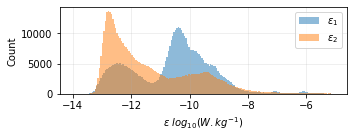

In [827]:
b = np.arange(-14,-5,0.05)
fig , axs =  plt.subplots(1,1, figsize=(5,2))
ax = axs
ax.hist(np.log10(E1),bins=b,alpha=0.5,label='$\epsilon_1$',density=False)
ax.hist(np.log10(E2),bins=b,alpha=0.5,label='$\epsilon_2$',density=False)
ax.legend(fontsize=10)
ax.set_xlabel('$\epsilon$ $log_{10}(W.kg^{-1})$')
ax.set_ylabel('Count')

ax.grid(alpha=0.25)

fig.tight_layout(pad=1)
figname = 'PDF'
fig.savefig('/Users/floriankokoszka/Desktop/data/microrider/local/'+'plots/'+ figname+ '.pdf')
fig.savefig('/Users/floriankokoszka/Desktop/data/microrider/local/'+'plots/'+ figname+ '.png',dpi= 600)
#plt.close(fig)
        

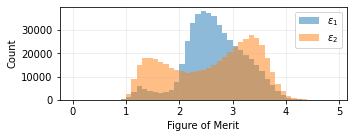

In [828]:
b = np.arange(0,5,0.1)
fig , axs =  plt.subplots(1,1, figsize=(5,2))
ax = axs
ax.hist(FM1,bins=b,alpha=0.5,label='$\epsilon_1$',density=False)
ax.hist(FM2,bins=b,alpha=0.5,label='$\epsilon_2$',density=False)
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
ax.set_xlabel('Figure of Merit')
ax.set_ylabel('Count')

fig.tight_layout(pad=1)
figname = 'FM'
fig.savefig('/Users/floriankokoszka/Desktop/data/microrider/local/'+'plots/'+ figname+ '.pdf')
fig.savefig('/Users/floriankokoszka/Desktop/data/microrider/local/'+'plots/'+ figname+ '.png',dpi= 600)
#plt.close(fig)
        
    

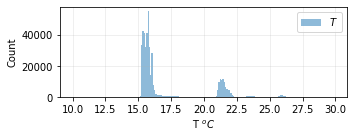

In [829]:
b = np.arange(10,30,0.1)
fig , axs =  plt.subplots(1,1, figsize=(5,2))
ax = axs
ax.hist(T,bins=b,alpha=0.5,label='$T$',density=False)
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
ax.set_xlabel('T $^o C$')
ax.set_ylabel('Count')

fig.tight_layout(pad=1)
figname = 'T'
fig.savefig('/Users/floriankokoszka/Desktop/data/microrider/local/'+'plots/'+ figname+ '.pdf')
fig.savefig('/Users/floriankokoszka/Desktop/data/microrider/local/'+'plots/'+ figname+ '.png',dpi= 600)
#plt.close(fig)



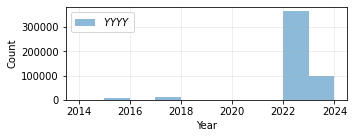

In [832]:
b = np.arange(2014,2025,1)
fig , axs =  plt.subplots(1,1, figsize=(5,2))
ax = axs
ax.hist(YYYY,bins=b,alpha=0.5,label='$YYYY$',density=False)
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
ax.set_xlabel('Year')
ax.set_ylabel('Count')

fig.tight_layout(pad=1)
figname = 'YYYY'
fig.savefig('/Users/floriankokoszka/Desktop/data/microrider/local/'+'plots/'+ figname+ '.pdf')
fig.savefig('/Users/floriankokoszka/Desktop/data/microrider/local/'+'plots/'+ figname+ '.png',dpi= 600)
#plt.close(fig)

In [835]:
yu = np.unique(YYYY)
yu

array([2015, 2017, 2018, 2022, 2023])

2015 6942
2017 10034
2018 235
2022 365480
2023 97355


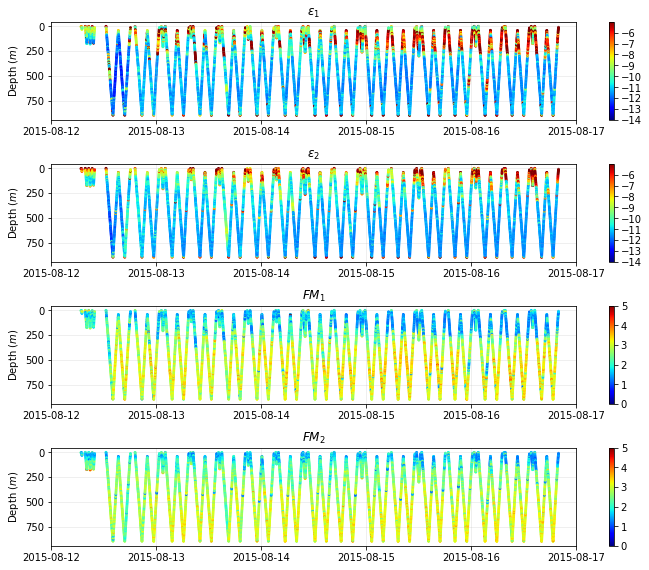

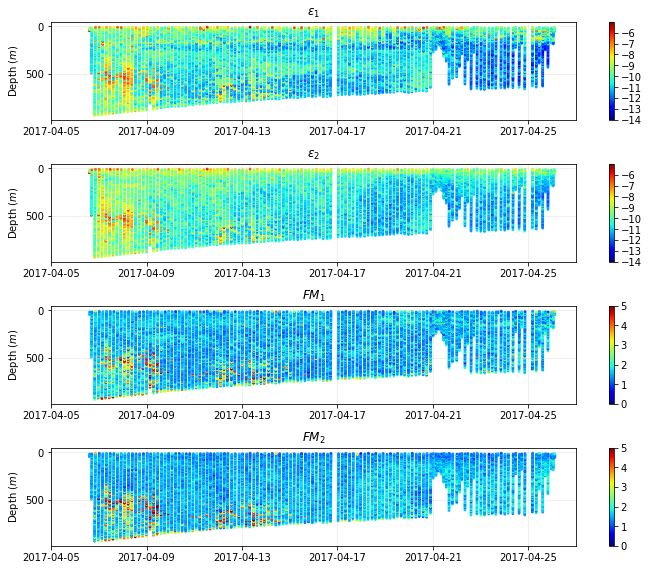

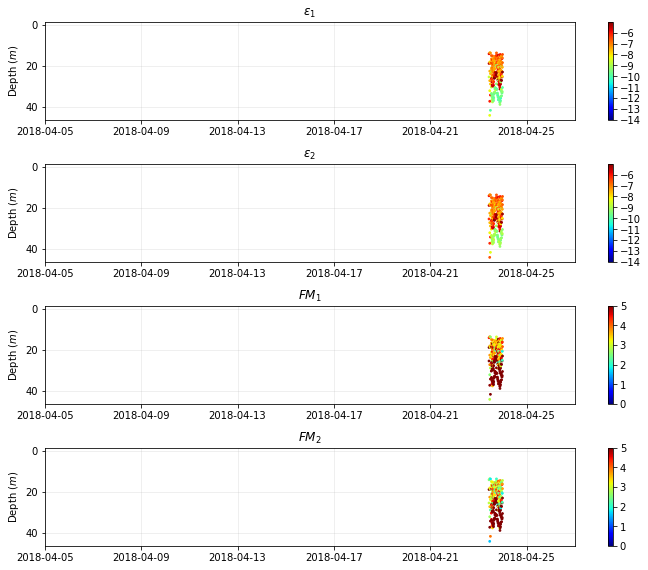

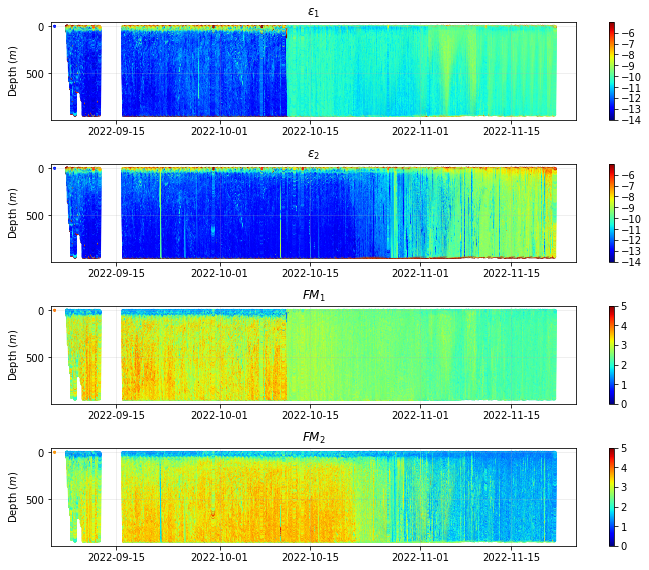

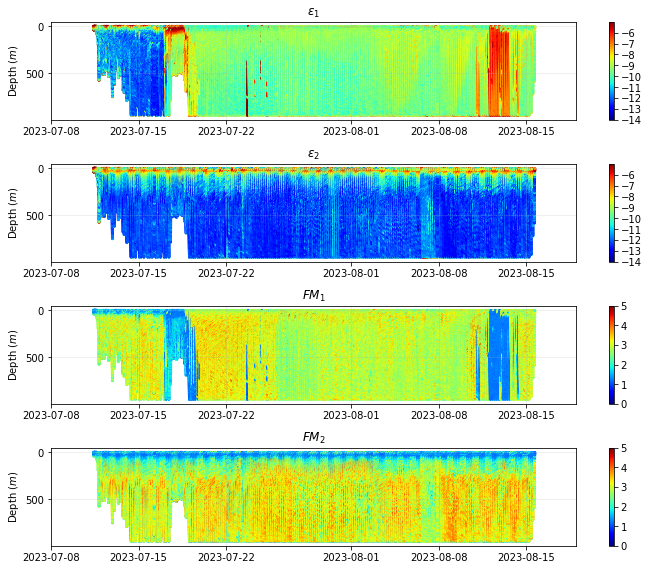

In [891]:
for u in range(0,len(yu)):
    u
    
#for u in range(0,1):   

    f = np.where(YYYY == yu[u])[0]
    print(yu[u],len(f))

    v1 = -14
    v2 = -5
    b = np.arange(-14,-5,1)
    mrks = 3

    fig , axs =  plt.subplots(4,1, figsize=(10,8))
    ax = axs[0]
    cax = ax.scatter(DT[f], ZE[f], s= mrks, c=np.log10(E1[f]), vmin=v1, vmax=v2,cmap='jet')
    ax.grid(alpha=.25)
    ax.invert_yaxis()
    cbar = fig.colorbar(cax, ticks=b)
    ax.set_ylabel('Depth $(m)$')
    ax.set_title('$\epsilon_1$')

    ax = axs[1]
    cax = ax.scatter(DT[f], ZE[f], s= mrks, c=np.log10(E2[f]), vmin=v1, vmax=v2,cmap='jet')
    ax.grid(alpha=.25)
    ax.invert_yaxis()
    cbar = fig.colorbar(cax, ticks=b)
    ax.set_ylabel('Depth $(m)$')
    ax.set_title('$\epsilon_2$')



    v1 = 0
    v2 = 5
    b = np.arange(0,5+1,1)

    ax = axs[2]
    cax = ax.scatter(DT[f], ZE[f], s= mrks, c=FM1[f], vmin=v1, vmax=v2,cmap='jet')
    ax.grid(alpha=.25)
    ax.invert_yaxis()
    cbar = fig.colorbar(cax, ticks=b)
    ax.set_ylabel('Depth $(m)$')
    ax.set_title('$FM_1$')

    ax = axs[3]
    cax = ax.scatter(DT[f], ZE[f], s= mrks, c=FM2[f], vmin=v1, vmax=v2,cmap='jet')
    ax.grid(alpha=.25)
    ax.invert_yaxis()
    cbar = fig.colorbar(cax, ticks=b)
    ax.set_ylabel('Depth $(m)$')
    ax.set_title('$FM_2$')



    for sb in range(0,3+1):
        ax = axs[sb]
        if yu[u] == 2015: dt1 = datetime(2015,8,12);  dt2 = datetime(2015,8,17)
        elif yu[u] == 2017: dt1 = datetime(2017,4,5);  dt2 = datetime(2017,4,27)
        elif yu[u] == 2018: dt1 = datetime(2018,4,5);  dt2 = datetime(2018,4,27)
        elif yu[u] == 2022: dt1 = datetime(2022,9,5);  dt2 = datetime(2022,11,25)
        elif yu[u] == 2023: dt1 = datetime(2023,7,8);  dt2 = datetime(2023,8,19)

        ax.set_xlim(dt1,dt2)


    fig.tight_layout(pad=1)
    
    figname = 'scatter_EPSI_FM_'+str(yu[u])
    fig.savefig('/Users/floriankokoszka/Desktop/data/microrider/local/'+'plots/'+ figname+ '.pdf')
    fig.savefig('/Users/floriankokoszka/Desktop/data/microrider/local/'+'plots/'+ figname+ '.png',dpi= 600)
    #plt.close(fig)



2015 6942
2017 10034
2018 235
2022 365480
2023 97355


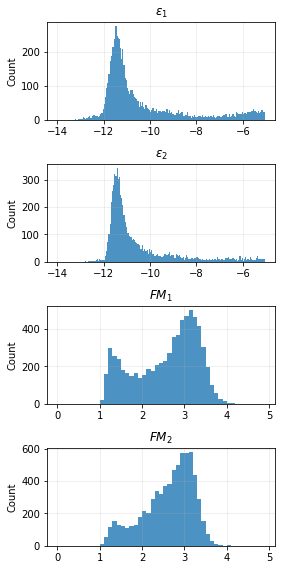

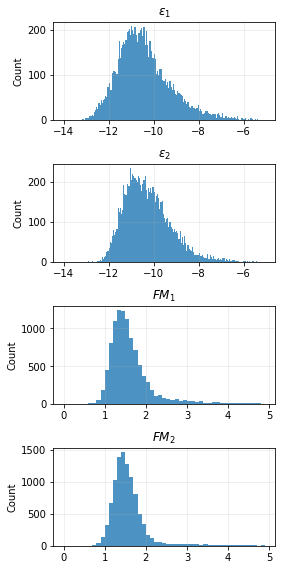

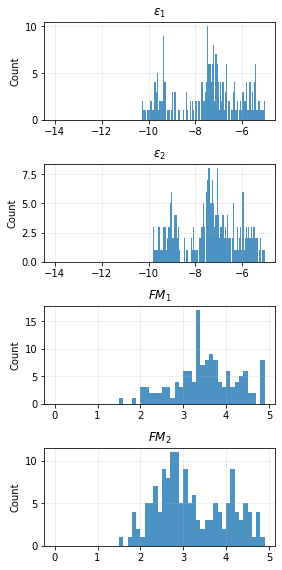

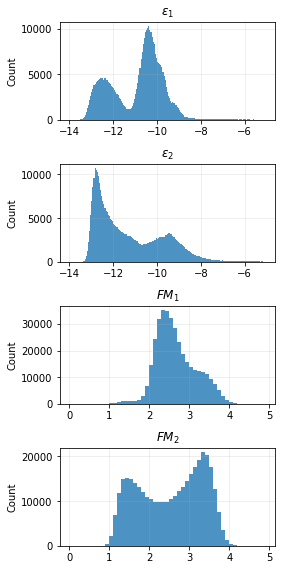

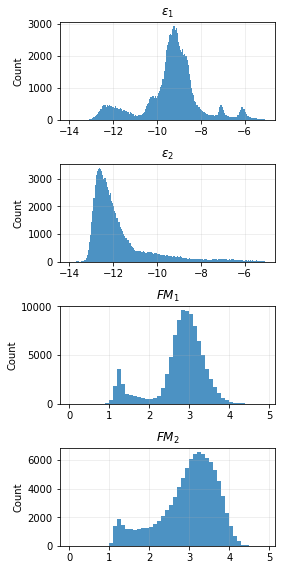

In [892]:
for u in range(0,len(yu)):
    u
    
#for u in range(0,1):   
    f = np.where(YYYY == yu[u])[0]
    print(yu[u],len(f))



    b = np.arange(-14,-5,0.05)


    fig , axs =  plt.subplots(4,1, figsize=(4,8))
    ax = axs[0]
    ax.hist(np.log10(E1[f]),bins=b,alpha=0.8,label='$\epsilon_1$',density=False)
    ax.grid(alpha=.25)
    ax.set_ylabel('Count')
    ax.set_title('$\epsilon_1$')

    ax = axs[1]
    ax.hist(np.log10(E2[f]),bins=b,alpha=0.8,label='$\epsilon_2$',density=False)
    ax.grid(alpha=.25)
    ax.set_ylabel('Count')
    ax.set_title('$\epsilon_2$')



    b = np.arange(0,5,0.1)


    ax = axs[2]
    ax.hist((FM1[f]),bins=b,alpha=0.8,label='$\epsilon_1$',density=False)
    ax.grid(alpha=.25)
    ax.set_ylabel('Count')
    ax.set_title('$FM_1$')
    
    
    ax = axs[3]
    ax.hist((FM2[f]),bins=b,alpha=0.8,label='$\epsilon_2$',density=False)
    ax.grid(alpha=.25)
    ax.set_ylabel('Count')
    ax.set_title('$FM_2$')





    fig.tight_layout(pad=1)

    figname = 'histograms_EPSI_FM_'+str(yu[u])
    fig.savefig('/Users/floriankokoszka/Desktop/data/microrider/local/'+'plots/'+ figname+ '.pdf')
    fig.savefig('/Users/floriankokoszka/Desktop/data/microrider/local/'+'plots/'+ figname+ '.png',dpi= 600)
    #plt.close(fig)

